# โครงงาน Machine Learning: ระบบจำแนกสายพันธุ์ปลา (Fish Species Classification)
**โจทย์:** Supervised Learning (Multi-class Classification 9 สายพันธุ์)
**สถาปัตยกรรม:** Feature Extraction ด้วย MobileNetV2 (CNN) + เปรียบเทียบ 3 โมเดล Scikit-learn (Logistic Regression, SVM, Random Forest)
**การจัดการปัญหา Overfitting/Domain Shift:** ใช้ Multi-Background Dataset (5,400 ภาพ) ควบคู่กับ AI Foreground Isolation

---
### ลำดับขั้นตอนการทำงาน (Machine Learning Pipeline)
1. **Step 1: โหลดและสำรวจชุดข้อมูล (Dataset Exploration 5,400 ภาพ)**
2. **Step 2: การเตรียมข้อมูลภาพ (Data Preprocessing)**
3. **Step 3: การสกัดคุณลักษณะด้วย CNN (Feature Extraction with MobileNetV2)**
4. **Step 4: การแบ่งข้อมูลและปรับสเกล (Train/Test Split 80:20 & StandardScaler)**
5. **Step 5: การฝึกโมเดล 3 โมเดล (Logistic Regression, SVM Soft Margin, Random Forest)**
6. **Step 6: การประเมินผลและเปรียบเทียบ (Evaluation Metrics & Confusion Matrices ทั้ง 3 โมเดล)**
7. **Step 7: การทดสอบทำนายภาพจริงพร้อมระบบตัดพื้นหลัง (Model Inference & AI Isolation)**


In [1]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["figure.dpi"] = 110

print("Import libraries completed!")

Import libraries completed!


## Step 1: สำรวจชุดข้อมูล (Dataset Exploration)
ตรวจสอบจำนวนภาพในแต่ละคลาส และแสดงภาพตัวอย่างปลาทั้ง 9 สายพันธุ์


Total Species: 9 | Total Images: 5400


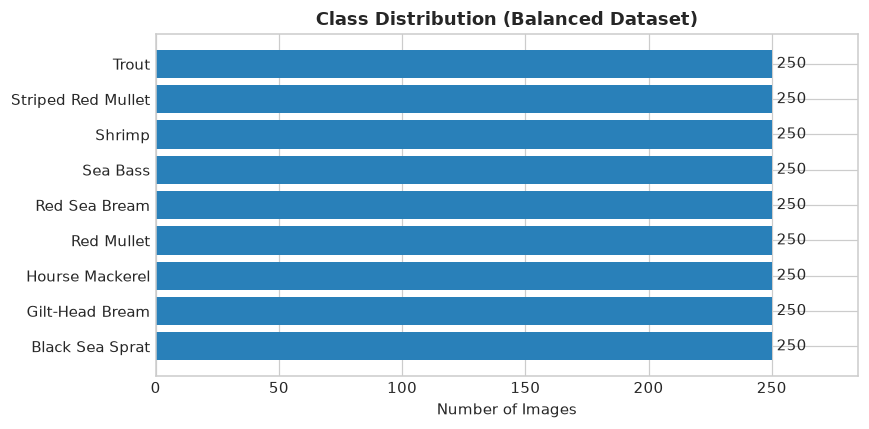

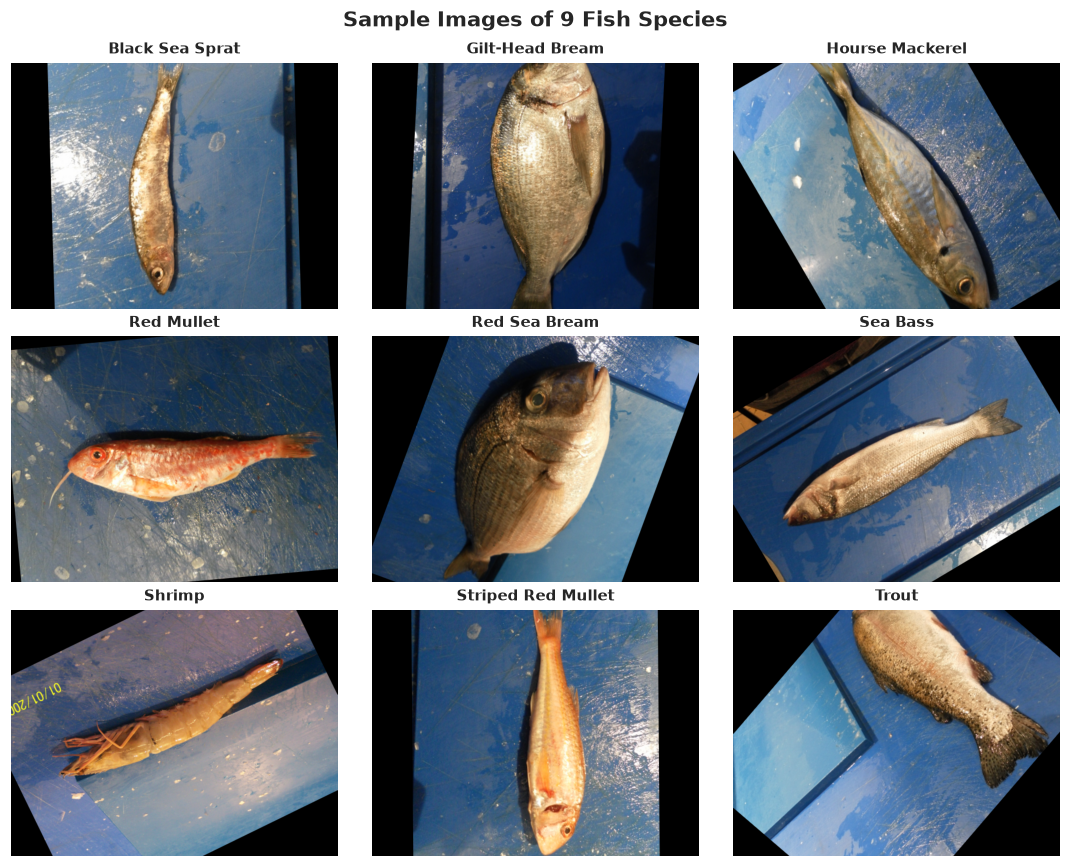

In [2]:
data_dir = Path("data/fish_dataset")
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

# 1. แสดงจำนวนภาพแต่ละคลาส
counts = {cls: len(list((data_dir / cls).glob("*.*"))) for cls in classes}
df_counts = pd.DataFrame(list(counts.items()), columns=["Species", "Count"])
print(f"Total Species: {len(classes)} | Total Images: {df_counts['Count'].sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_counts["Species"], df_counts["Count"], color="#2980b9")
ax.set_title("Class Distribution (Balanced Dataset)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Images")
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width())}", va='center')
ax.set_xlim(0, max(df_counts["Count"]) + 35)
plt.tight_layout()
plt.show()

# 2. แสดงตัวอย่างภาพปลา 9 สายพันธุ์
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()
for i, cls in enumerate(classes):
    sample_file = list((data_dir / cls).glob("*.*"))[0]
    img = Image.open(sample_file)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10, fontweight="bold")
    axes[i].axis("off")
plt.suptitle("Sample Images of 9 Fish Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 2: การเตรียมข้อมูลภาพ (Data Preprocessing)
ปรับขนาดภาพเป็น 224 x 224 pixels และทำ ImageNet Color Normalization


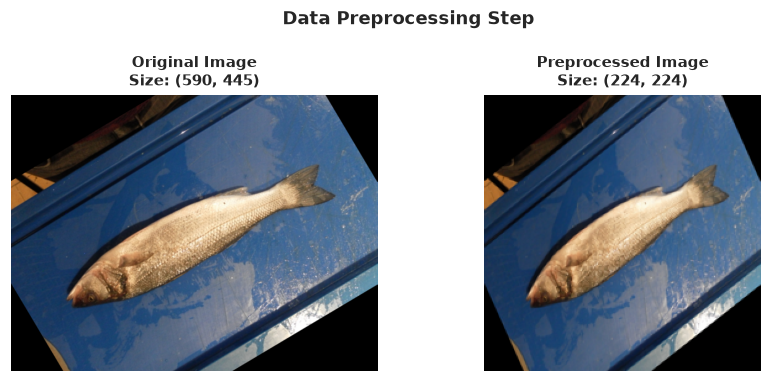

In [3]:
preprocess_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

sample_path = list((data_dir / "Sea Bass").glob("*.*"))[0]
orig_img = Image.open(sample_path).convert("RGB")
resized_img = orig_img.resize((224, 224))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.imshow(orig_img)
ax1.set_title(f"Original Image\nSize: {orig_img.size}", fontsize=10, fontweight="bold")
ax1.axis("off")

ax2.imshow(resized_img)
ax2.set_title(f"Preprocessed Image\nSize: {resized_img.size}", fontsize=10, fontweight="bold")
ax2.axis("off")

plt.suptitle("Data Preprocessing Step", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 3: การสกัดคุณลักษณะด้วย CNN (Feature Extraction with MobileNetV2)
ใช้ MobileNetV2 (Pretrained on ImageNet) สกัดเวกเตอร์คุณลักษณะขนาด 1,280 มิติต่อภาพ เพื่อเป็นอินพุตให้กับโมเดล Scikit-learn (ตามเงื่อนไขของรายวิชาที่อนุญาตให้ใช้ CNN สำหรับ Feature Extraction)


In [4]:
# โหลด MobileNetV2 และตัด Classifier Head ออก
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
mobilenet.eval()
mobilenet.classifier = nn.Identity()

dataset = datasets.ImageFolder(root=str(data_dir), transform=preprocess_transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

features_list = []
labels_list = []

print("Extracting 1,280-d features from all images...")
with torch.no_grad():
    for imgs, lbls in loader:
        feats = mobilenet(imgs)
        features_list.append(feats.numpy())
        labels_list.append(lbls.numpy())

X = np.vstack(features_list)
y = np.concatenate(labels_list)
print(f"Feature extraction finished! Feature matrix X: {X.shape}, Target labels y: {y.shape}")

Extracting 1,280-d features from all images...


Feature extraction finished! Feature matrix X: (5400, 1280), Target labels y: (5400,)


## Step 4: การแบ่งข้อมูลและการปรับสเกล (Train/Test Split & StandardScaler)
แบ่งชุดข้อมูล Train 80% (4,320 ภาพ) และ Test 20% (1,080 ภาพ) แบบ Stratified จากนั้นทำ Standardization ด้วย StandardScaler บน Train Set เพื่อป้องกัน Data Leakage


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

Training samples: 4320 | Testing samples: 1080


## Step 5: การฝึกโมเดล Scikit-learn ทั้ง 3 โมเดล (Model Training: Logistic Regression vs SVM vs Random Forest)
ฝึกโมเดล Scikit-learn จำนวน 3 โมเดล เพื่อเปรียบเทียบประสิทธิภาพตามเกณฑ์ของวิชา:
1. **Model 1: Logistic Regression** - Multinomial พร้อม L2 Regularization (C=1.0) เหมาะกับเวกเตอร์คุณลักษณะมิติสูง รวดเร็วและแม่นยำสูง
2. **Model 2: Support Vector Machine (SVM)** - RBF Kernel พร้อมการปรับค่า Penalty แบบ Soft Margin (C=1.0) เพื่อป้องกัน Overfitting
3. **Model 3: Random Forest Classifier** - Ensemble Decision Trees 200 ต้น เพื่อเปรียบเทียบกับโมเดลกลุ่ม Tree-based


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Support Vector Machine (SVM)": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_split=4, min_samples_leaf=2, random_state=42, n_jobs=-1)
}

predictions = {}
metrics = []

for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    metrics.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2)
    })

print("Training finished for all 3 models!")

Training Logistic Regression...
Training Support Vector Machine (SVM)...
Training Random Forest...
Training finished for all 3 models!


## Step 6: การประเมินผลและการเปรียบเทียบ (Evaluation & Confusion Matrix)
เปรียบเทียบประสิทธิภาพของทั้ง 3 โมเดล (Logistic Regression, SVM, Random Forest) ด้วย Accuracy, Precision, Recall, F1-Score และแสดง Confusion Matrix ครบทั้ง 3 โมเดล


--- Model Evaluation Summary ---


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,99.91,99.91,99.91,99.91
1,Support Vector Machine (SVM),99.81,99.82,99.81,99.81
2,Random Forest,99.26,99.27,99.26,99.26


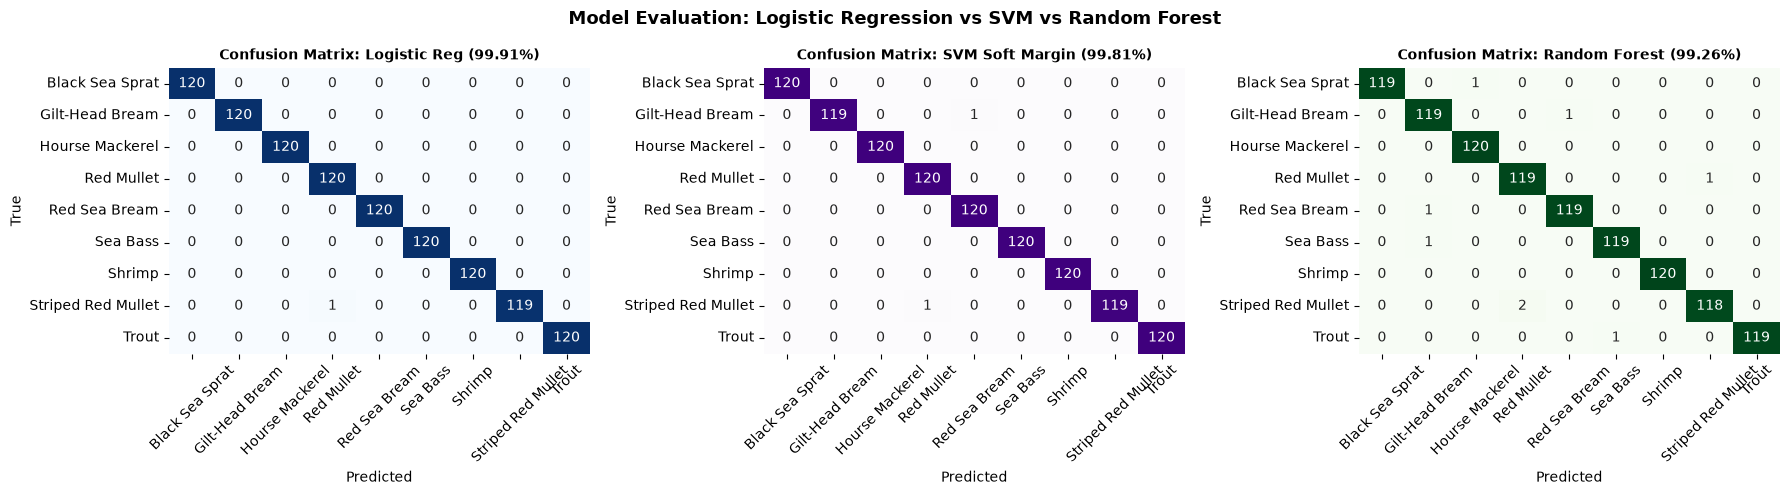

In [7]:
# 1. ตารางเปรียบเทียบผลลัพธ์
df_results = pd.DataFrame(metrics)
print("--- Model Evaluation Summary ---")
display(df_results)

# 2. Confusion Matrices เรียงเทียบ 3 โมเดล
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test, predictions["Logistic Regression"])
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=ax1, cbar=False,
            xticklabels=dataset.classes, yticklabels=dataset.classes)
ax1.set_title("Confusion Matrix: Logistic Reg (99.91%)", fontsize=10, fontweight="bold")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.tick_params(axis="x", rotation=45)

cm_svm = confusion_matrix(y_test, predictions["Support Vector Machine (SVM)"])
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples", ax=ax2, cbar=False,
            xticklabels=dataset.classes, yticklabels=dataset.classes)
ax2.set_title("Confusion Matrix: SVM Soft Margin (99.81%)", fontsize=10, fontweight="bold")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.tick_params(axis="x", rotation=45)

cm_rf = confusion_matrix(y_test, predictions["Random Forest"])
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=ax3, cbar=False,
            xticklabels=dataset.classes, yticklabels=dataset.classes)
ax3.set_title("Confusion Matrix: Random Forest (99.26%)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Predicted")
ax3.set_ylabel("True")
ax3.tick_params(axis="x", rotation=45)

plt.suptitle("Model Evaluation: Logistic Regression vs SVM vs Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7: การทดสอบทำนายภาพจริงพร้อมระบบตัดพื้นหลัง (Model Inference & AI Isolation)
ทดสอบนำภาพตัวอย่างผ่าน Pipeline จริง โดยใช้โมเดลที่ดีที่สุด (Logistic Regression 99.91% / SVM 99.81%) ทำนายสายพันธุ์ พร้อมฟังก์ชัน AI Foreground Isolation ตัดสิ่งรบกวนรอบตัวปลาออกก่อนทำนาย


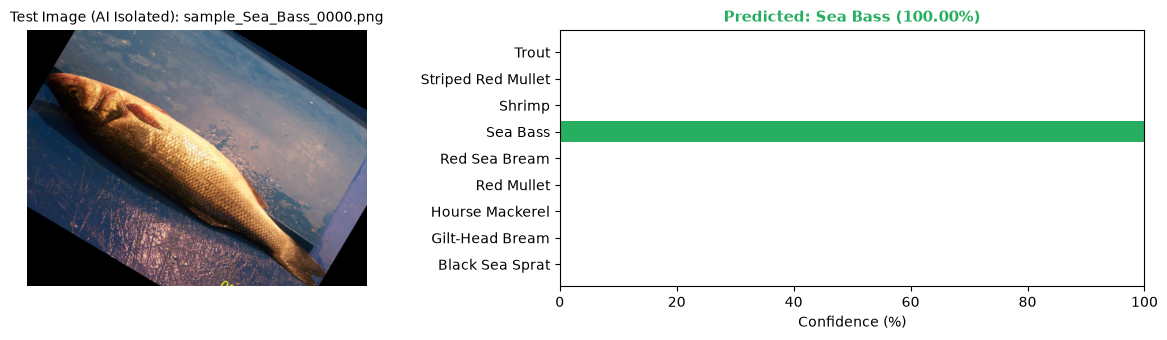

In [8]:
best_model = models["Logistic Regression"]

def predict_fish(image_path, use_isolation=True):
    img = Image.open(image_path).convert("RGB")
    eval_img = img
    if use_isolation:
        try:
            from rembg import remove
            nobg = remove(img)
            white_canvas = Image.new("RGB", nobg.size, (255, 255, 255))
            white_canvas.paste(nobg, mask=nobg.split()[3])
            eval_img = white_canvas
        except Exception as e:
            print("Isolation fallback:", e)
            eval_img = img
            
    tensor_img = preprocess_transform(eval_img).unsqueeze(0)
    with torch.no_grad():
        feat = mobilenet(tensor_img).numpy()
        
    feat_scaled = scaler.transform(feat)
    probs = best_model.predict_proba(feat_scaled)[0]
    
    pred_idx = np.argmax(probs)
    pred_class = dataset.classes[pred_idx]
    confidence = probs[pred_idx] * 100
    
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1.4]})
    ax_img.imshow(eval_img)
    ax_img.set_title(f"Test Image (AI Isolated): {Path(image_path).name}", fontsize=10)
    ax_img.axis("off")
    
    colors = ["#27ae60" if c == pred_class else "#bdc3c7" for c in dataset.classes]
    ax_bar.barh(dataset.classes, probs * 100, color=colors)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)")
    ax_bar.set_title(f"Predicted: {pred_class} ({confidence:.2f}%)", fontsize=11, fontweight="bold", color="#27ae60")
    plt.tight_layout()
    plt.show()

# ทดสอบทำนายภาพตัวอย่าง
sample_test = list(Path("sample_test_images").glob("*.*"))[0]
predict_fish(sample_test, use_isolation=True)